<a href="https://colab.research.google.com/github/KSaubhagya/Prediction-Module/blob/main/Risk_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns

2.Load Data

In [2]:
from google.colab import files
uploaded = files.upload()


Saving dataset final - Prediction Module subset.csv to dataset final - Prediction Module subset.csv


In [3]:
df = pd.read_csv(list(uploaded.keys())[0])

In [4]:
# Standardize column names
df.columns = df.columns.str.strip()
print(df.columns.tolist())
df.head()

['Name', 'student_id', 'gender', 'program', 'gpa', 'previous_results', 'module_code', 'course_information', 'module_credits', 'ca_weight', 'final_exam_weight', 'ca_marks', 'final_exam_marks', 'total_marks', 'final_grade', 'lecture_attendance', 'attendance_percentage', 'assignment_marks', 'exam_results', 'late_arrivals', 'quiz_scores', 'submission_status', 'login_frequency', 'time_spent_lms', 'resources_accessed', 'forum_chat_activity', 'course_start_date', 'education_level', 'click_count', 'assessment_date', 'assessment_type', 'assessment_score', 'assessment_max_score', 'Learning_Style', 'week_number', 'week_start_date', 'week_end_date', 'assignment_due_date', 'assignment_submission_date', 'sessions_attended', 'total_sessions_held', 'click_timestamp', 'module_id', 'pass_fail_status', 'assignment_max_marks']


,Name,student_id,gender,program,gpa,previous_results,module_code,course_information,module_credits,ca_weight,...,week_start_date,week_end_date,assignment_due_date,assignment_submission_date,sessions_attended,total_sessions_held,click_timestamp,module_id,pass_fail_status,assignment_max_marks
0,Nadeesha Baskaran,ST725,Female,IT,3.11,Good,IN2101,Object Oriented Programming,3.0,40,...,2025-06-30,2025-07-06,2025-07-08,2025-07-07,24,25,2025-05-05 20:40:00,MOD-IN2101,Pass,40
1,Amila Piyarathna,ST383,Male,IT,3.02,Good,IN2901,Software Development Project,4.0,100,...,2025-07-06,2025-07-12,2025-07-12,2025-07-15,15,27,2025-05-25 13:19:00,MOD-IN2901,Pass,100
2,Amila Piyarathna,ST383,Male,IT,3.02,Good,CM2131,Essentials of Mathematical Methods,2.5,30,...,2025-04-27,2025-05-03,2025-05-04,2025-05-08,18,26,2025-05-25 14:00:00,MOD-CM2131,Pass,30
3,Amila Piyarathna,ST383,Male,IT,3.02,Good,IN2101,Object Oriented Programming,3.0,40,...,2025-04-13,2025-04-19,2025-04-20,2025-04-24,12,25,2025-05-25 12:57:00,MOD-IN2101,Pass,40
4,Amila Piyarathna,ST383,Male,IT,3.02,Good,IN2321,Computer Architecture,2.5,30,...,2025-05-11,2025-05-17,2025-05-18,2025-05-22,18,30,2025-05-25 13:11:00,MOD-IN2321,Pass,30


3. Initial Cleaning

In [5]:
# Remove duplicates
print("Duplicates found:", df.duplicated().sum())
df = df.drop_duplicates()


Duplicates found: 0


In [6]:
# Check missing values
print(df.isnull().sum())

Name                          0
student_id                    0
gender                        0
program                       0
gpa                           0
previous_results              0
module_code                   0
course_information            0
module_credits                0
ca_weight                     0
final_exam_weight             0
ca_marks                      0
final_exam_marks              0
total_marks                   0
final_grade                   0
lecture_attendance            0
attendance_percentage         0
assignment_marks              0
exam_results                  0
late_arrivals                 0
quiz_scores                   0
submission_status             0
login_frequency               0
time_spent_lms                0
resources_accessed            0
forum_chat_activity           0
course_start_date             0
education_level               0
click_count                   0
assessment_date               0
assessment_type               0
assessme

4.Handle Missing Values

In [7]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

In [8]:
print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

Numerical columns: ['gpa', 'module_credits', 'ca_weight', 'final_exam_weight', 'ca_marks', 'final_exam_marks', 'total_marks', 'lecture_attendance', 'attendance_percentage', 'assignment_marks', 'exam_results', 'late_arrivals', 'quiz_scores', 'login_frequency', 'time_spent_lms', 'resources_accessed', 'forum_chat_activity', 'click_count', 'assessment_score', 'assessment_max_score', 'sessions_attended', 'total_sessions_held', 'assignment_max_marks']
Categorical columns: ['Name', 'student_id', 'gender', 'program', 'previous_results', 'module_code', 'course_information', 'final_grade', 'submission_status', 'course_start_date', 'education_level', 'assessment_date', 'assessment_type', 'Learning_Style', 'week_number', 'week_start_date', 'week_end_date', 'assignment_due_date', 'assignment_submission_date', 'click_timestamp', 'module_id', 'pass_fail_status']


In [9]:
# Impute numerical missing values with median
num_imputer = SimpleImputer(strategy='median')
df[numerical_cols] = num_imputer.fit_transform(df[numerical_cols])

In [10]:
# Impute categorical missing values with most frequent
cat_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

Dataset Shape: (6124, 45)

Numerical Columns: 23
Categorical Columns: 22


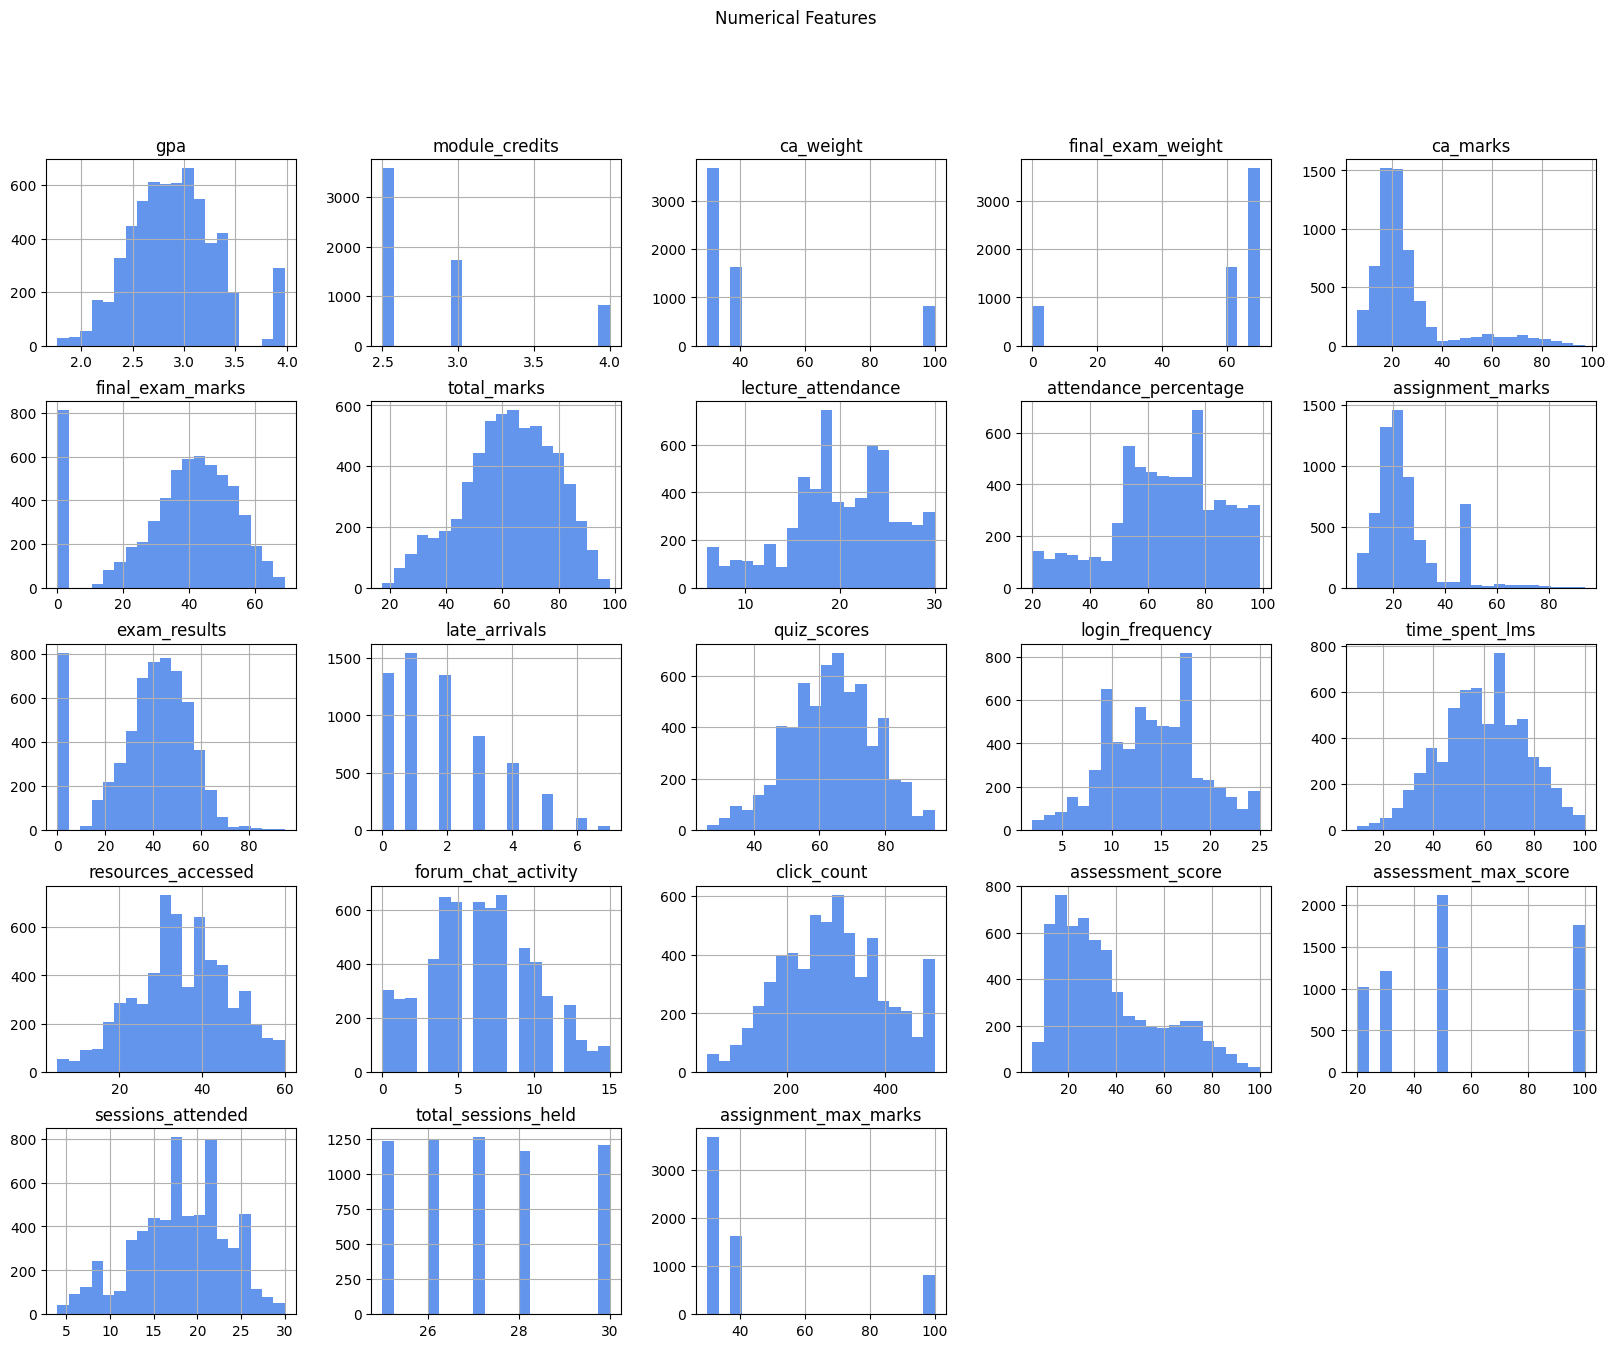

In [11]:
def run_eda(df):
    import matplotlib.pyplot as plt
    import seaborn as sns

    num_cols = df.select_dtypes(include=['int64', 'float64']).columns
    cat_cols = df.select_dtypes(include=['object']).columns

    print("Dataset Shape:", df.shape)
    print("\nNumerical Columns:", len(num_cols))
    print("Categorical Columns:", len(cat_cols))

    # Numerical distributions
    df[num_cols].hist(
        bins=20,
        figsize=(20,15),
        color='cornflowerblue'
    )
    plt.suptitle("Numerical Features")
    plt.show()

run_eda(df)

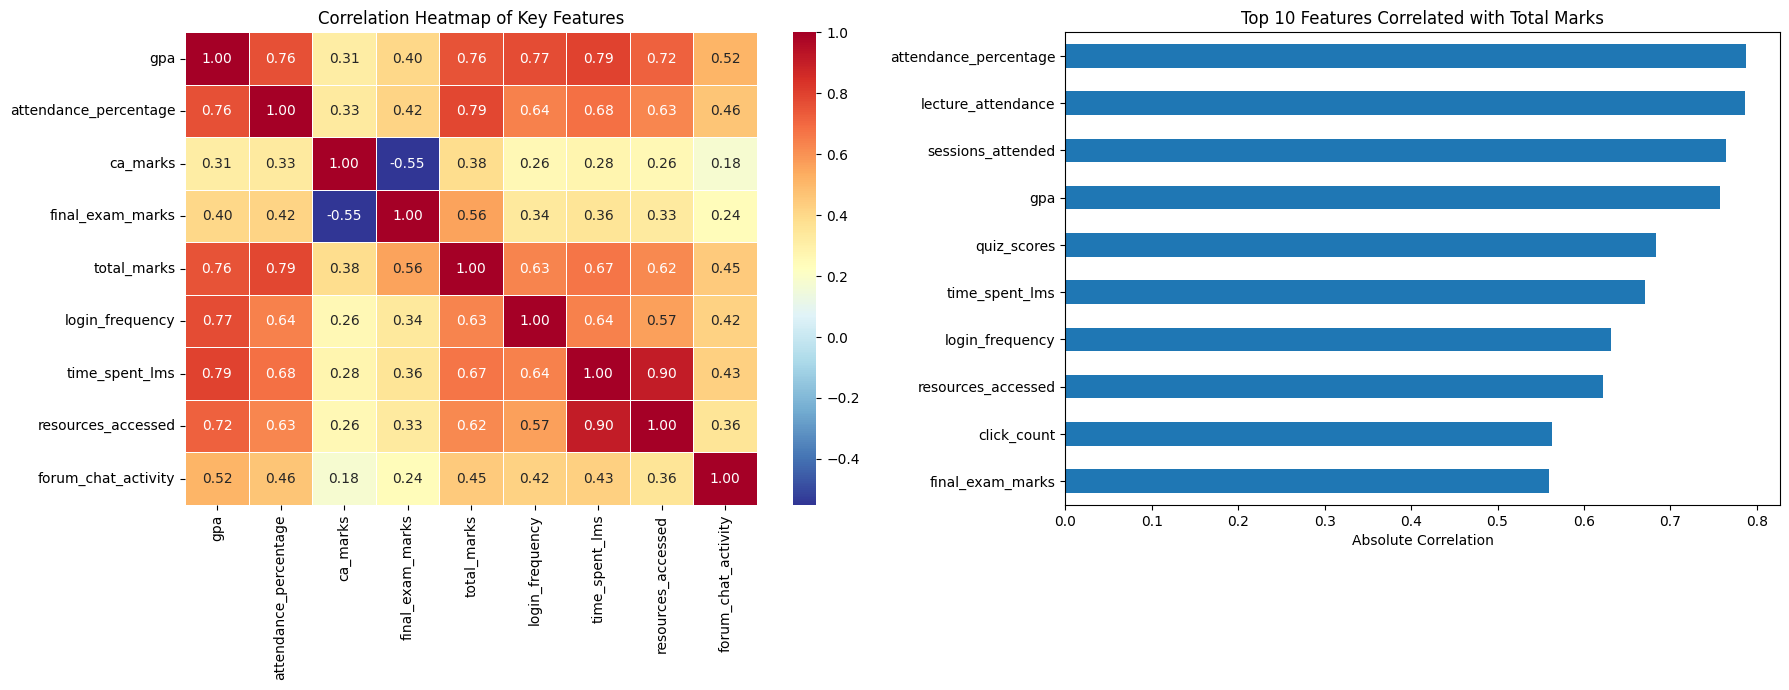

In [12]:
# Key features for heatmap
heatmap_features = [
    'gpa',
    'attendance_percentage',
    'ca_marks',
    'final_exam_marks',
    'total_marks',
    'login_frequency',
    'time_spent_lms',
    'resources_accessed',
    'forum_chat_activity'
]

# Create figure with 2 plots
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Heatmap
sns.heatmap(
    df[heatmap_features].corr(),
    annot=True,
    cmap='RdYlBu_r',
    fmt='.2f',
    linewidths=0.5,
    ax=axes[0]
)

axes[0].set_title('Correlation Heatmap of Key Features')


# Top Correlations with Total Marks
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

corr_target = (
    df[num_cols]
    .corr()['total_marks']
    .drop('total_marks')
    .abs()
    .sort_values(ascending=False)
    .head(10)
)

corr_target.sort_values().plot(
    kind='barh',
    ax=axes[1]
)

axes[1].set_title('Top 10 Features Correlated with Total Marks')
axes[1].set_xlabel('Absolute Correlation')

plt.tight_layout()
plt.show()

5. CATEGORICAL ENCODING (One-Hot)

In [13]:
# Identify date columns to exclude from one-hot encoding
date_like_cols = ['course_start_date', 'assessment_date']
ohe_cols = [c for c in categorical_cols if c not in date_like_cols]

In [14]:
print("Columns to one-hot encode:", ohe_cols)

Columns to one-hot encode: ['Name', 'student_id', 'gender', 'program', 'previous_results', 'module_code', 'course_information', 'final_grade', 'submission_status', 'education_level', 'assessment_type', 'Learning_Style', 'week_number', 'week_start_date', 'week_end_date', 'assignment_due_date', 'assignment_submission_date', 'click_timestamp', 'module_id', 'pass_fail_status']


In [15]:
# One-hot encode
df_encoded = pd.get_dummies(df, columns=ohe_cols, drop_first=False)


6. TEMPORAL FEATURES

In [16]:
df_encoded['course_start_date'] = pd.to_datetime(df_encoded['course_start_date'], errors='coerce')
df_encoded['assessment_date'] = pd.to_datetime(df_encoded['assessment_date'], errors='coerce')

In [17]:
# Week number relative to course start
df_encoded['week_number'] = (
    (df_encoded['assessment_date'] - df_encoded['course_start_date']).dt.days // 7
) + 1

In [18]:
# Days since course start
df_encoded['days_since_start'] = (
    df_encoded['assessment_date'] - df_encoded['course_start_date']
).dt.days

7. FEATURE ENGINEERING (multi-source)

In [19]:
# Engagement score (LMS clicks + time + forum activity)
df_encoded['engagement_score'] = (
    df_encoded['click_count'].fillna(0) +
    df_encoded['time_spent_lms'].fillna(0) +
    df_encoded['forum_chat_activity'].fillna(0)
)

In [20]:
# Assessment performance ratio
df_encoded['assessment_ratio'] = (
    df_encoded['assessment_score'] / df_encoded['assessment_max_score']
)

In [21]:
# Weighted CA contribution
df_encoded['weighted_score'] = df_encoded['assessment_ratio'] * df_encoded['ca_weight']

In [22]:
# Low attendance flag
df_encoded['low_attendance_flag'] = (df_encoded['attendance_percentage'] < 75).astype(int)

**Convert to risk categories **

≥75%: Student demonstrates strong academic performance and engagement (Low Risk).

50–74%: Student shows moderate performance and may require monitoring (Medium Risk).

<50%: Student has weak performance and engagement, indicating a high likelihood of academic difficulty (High Risk).

['A-' 'B+' 'B' 'C+' 'C' 'F' 'A' 'A+' 'B-' 'C-']
['Pass' 'Fail']
pass_fail_status  Fail  Pass
risk_category               
High Risk          632     1
Low Risk             0  4191
Medium Risk          0  1300
risk_category
Low Risk       4191
Medium Risk    1300
High Risk       633
Name: count, dtype: int64


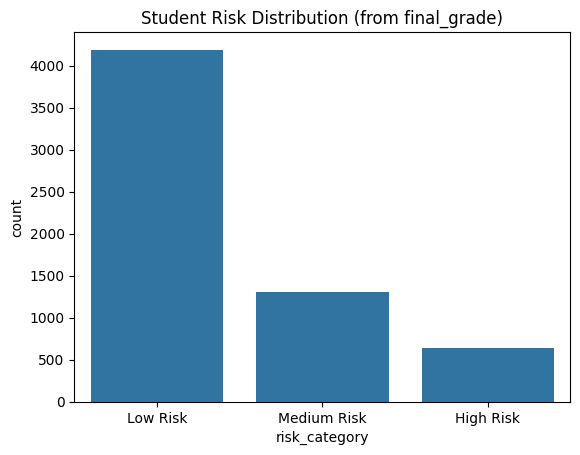

In [23]:
# ---------- Define modeling target from final_grade ----------

print(df["final_grade"].unique())
print(df["pass_fail_status"].unique())

# Grade -> risk mapping based on institutional grading bands:
# A/A+/A- and B+/B  -> Low Risk (strong standing)
# B-/C+/C           -> Medium Risk (passing but weak)
# C-/F              -> High Risk (failing or borderline failing)
grade_risk_map = {
    "A+": "Low Risk", "A": "Low Risk", "A-": "Low Risk", "B+": "Low Risk", "B": "Low Risk",
    "B-": "Medium Risk", "C+": "Medium Risk", "C": "Medium Risk",
    "C-": "High Risk", "F": "High Risk"
}

df["risk_category"] = df["final_grade"].map(grade_risk_map)

# Sanity check against pass_fail_status: every High Risk 'F' row should be 'Fail'
print(pd.crosstab(df["risk_category"], df["pass_fail_status"]))

print(df["risk_category"].value_counts())

sns.countplot(
    data=df,
    x="risk_category",
    order=["Low Risk", "Medium Risk", "High Risk"]
)
plt.title("Student Risk Distribution (from final_grade)")
plt.show()

In [24]:
# Select Features

features = [
    "attendance_percentage",
    "assessment_score",
    "click_count",
    "login_frequency",
    "time_spent_lms",
    "resources_accessed",
    "forum_chat_activity",
    "engagement_score",
    "gpa",
    "days_since_start",
    "week_number"
]

In [25]:
target = "risk_category"

In [26]:
# encode target
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df[target] = le.fit_transform(df[target])
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'High Risk': np.int64(0), 'Low Risk': np.int64(1), 'Medium Risk': np.int64(2)}


In [27]:
# train/test split
from sklearn.model_selection import train_test_split

X = df_encoded[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [28]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred_lr))
print(classification_report(y_test, pred_lr))

Accuracy: 0.7444897959183674
              precision    recall  f1-score   support

           0       0.55      0.39      0.46       127
           1       0.83      0.95      0.89       838
           2       0.36      0.24      0.29       260

    accuracy                           0.74      1225
   macro avg       0.58      0.53      0.54      1225
weighted avg       0.70      0.74      0.72      1225



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


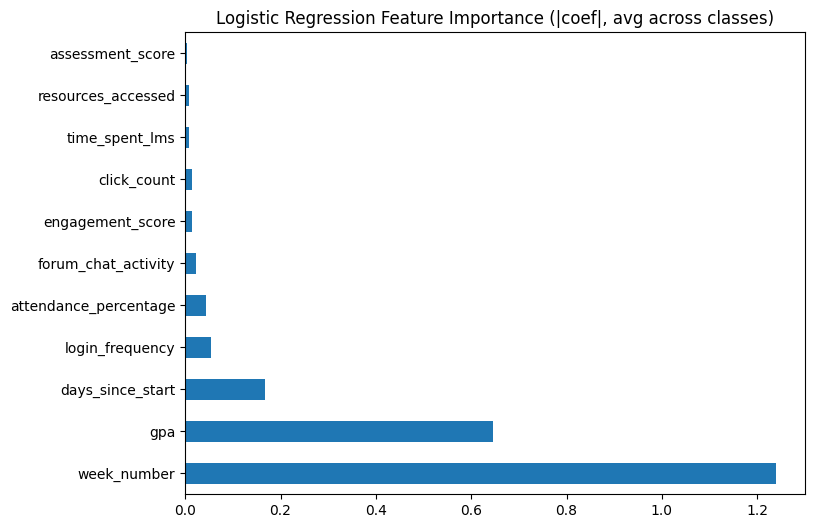

In [29]:
# Logistic Regression "importance" via coefficient magnitude (averaged across classes)
lr_importance = pd.Series(
    np.abs(lr.coef_).mean(axis=0),
    index=features
).sort_values(ascending=False)

lr_importance.plot(kind="barh", figsize=(8,6))
plt.title("Logistic Regression Feature Importance (|coef|, avg across classes)")
plt.show()

In [30]:
results_lr = X_test.copy()
results_lr["Predicted_Risk"] = le.inverse_transform(pred_lr)
results_lr["Final_Grade"] = df.loc[X_test.index, "final_grade"].values
results_lr["Pass_Fail"] = df.loc[X_test.index, "pass_fail_status"].values
print(results_lr[["Predicted_Risk", "Final_Grade", "Pass_Fail"]].head())

     Predicted_Risk Final_Grade Pass_Fail
5030       Low Risk           A      Pass
6006       Low Risk          B+      Pass
3718       Low Risk           B      Pass
2281      High Risk           F      Fail
3213       Low Risk          B+      Pass


In [31]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred_rf))
print(classification_report(y_test, pred_rf))

Accuracy: 0.7461224489795918
              precision    recall  f1-score   support

           0       0.58      0.46      0.52       127
           1       0.86      0.91      0.88       838
           2       0.39      0.34      0.36       260

    accuracy                           0.75      1225
   macro avg       0.61      0.57      0.59      1225
weighted avg       0.73      0.75      0.74      1225



In [32]:
############################################################
# Compare predicted risk with final academic performance
############################################################

results = X_test.copy()

results["Predicted_Risk"] = le.inverse_transform(pred_rf)

results["Final_Grade"] = (
    df.loc[X_test.index, "final_grade"].values
)

results["Pass_Fail"] = (
    df.loc[X_test.index, "pass_fail_status"].values
)

print(results[
    ["Predicted_Risk",
     "Final_Grade",
     "Pass_Fail"]
].head())

     Predicted_Risk Final_Grade Pass_Fail
5030       Low Risk           A      Pass
6006       Low Risk          B+      Pass
3718       Low Risk           B      Pass
2281    Medium Risk           F      Fail
3213       Low Risk          B+      Pass


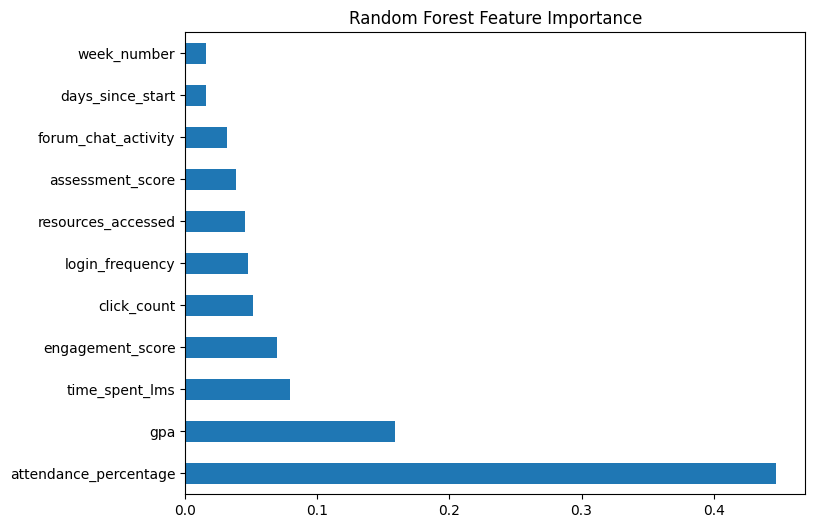

In [33]:
#   feature importance
importance = pd.Series(
    rf.feature_importances_,
    index=features
).sort_values(ascending=False)

importance.plot(kind="barh", figsize=(8,6))
plt.title("Random Forest Feature Importance")
plt.show()

In [34]:
# XG Boost
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective="multi:softmax",
    num_class=3,
    random_state=42,
    eval_metric="mlogloss"
)
xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred_xgb))
print(classification_report(y_test, pred_xgb))

Accuracy: 0.746938775510204
              precision    recall  f1-score   support

           0       0.57      0.57      0.57       127
           1       0.85      0.93      0.89       838
           2       0.36      0.24      0.29       260

    accuracy                           0.75      1225
   macro avg       0.59      0.58      0.58      1225
weighted avg       0.71      0.75      0.73      1225



In [35]:
results_xgb = X_test.copy()
results_xgb["Predicted_Risk"] = le.inverse_transform(pred_xgb)
results_xgb["Final_Grade"] = df.loc[X_test.index, "final_grade"].values
results_xgb["Pass_Fail"] = df.loc[X_test.index, "pass_fail_status"].values
print(results_xgb[["Predicted_Risk", "Final_Grade", "Pass_Fail"]].head())

     Predicted_Risk Final_Grade Pass_Fail
5030       Low Risk           A      Pass
6006       Low Risk          B+      Pass
3718       Low Risk           B      Pass
2281      High Risk           F      Fail
3213       Low Risk          B+      Pass


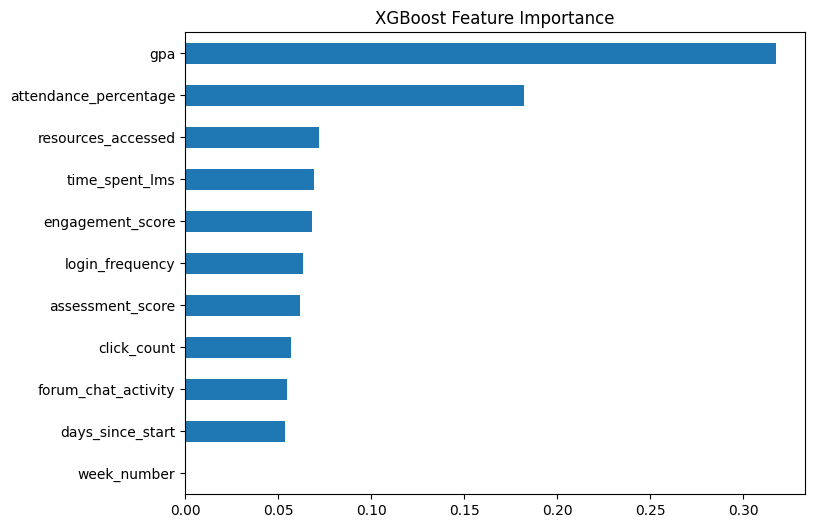

In [36]:
# feature importance of XG Boost
importance = pd.Series(
    xgb.feature_importances_,
    index=features
).sort_values()
importance.plot(kind="barh", figsize=(8,6))
plt.title("XGBoost Feature Importance")
plt.show()

                 Model  Accuracy
0  Logistic Regression  0.744490
1        Random Forest  0.746122
2              XGBoost  0.746939


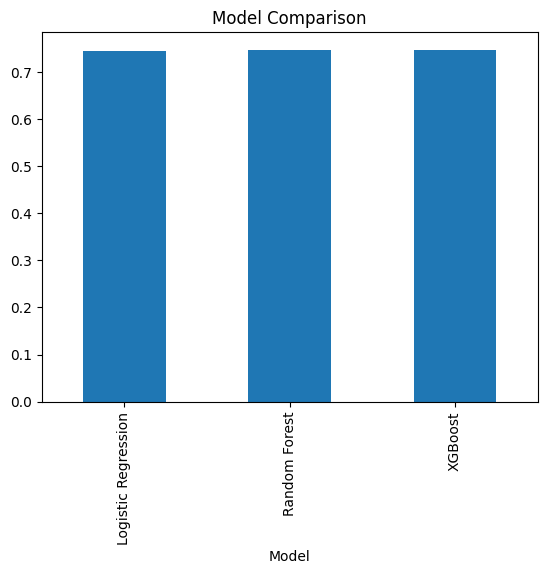

In [37]:
# Compare the models
results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[
        accuracy_score(y_test,pred_lr),
        accuracy_score(y_test,pred_rf),
        accuracy_score(y_test,pred_xgb)
    ]
})
print(results)
results.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    legend=False,
    title="Model Comparison"
)

plt.show()

FEATURE IMPORTANCE

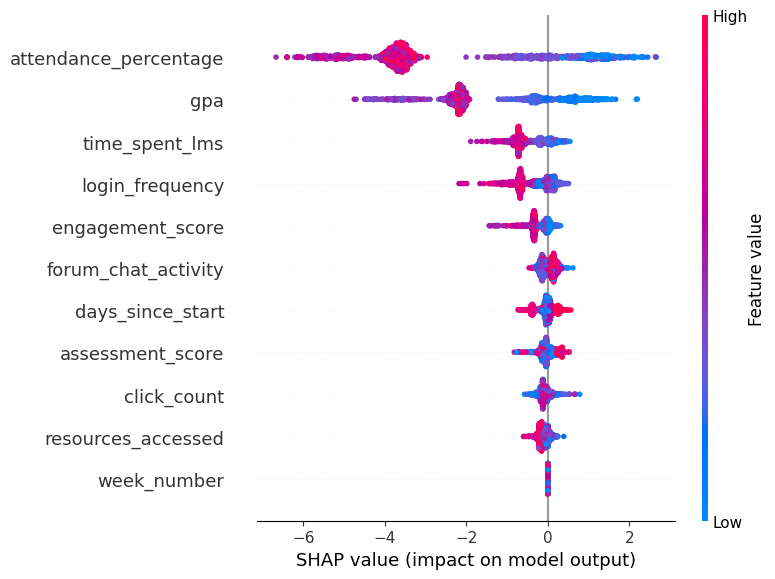

In [39]:
!pip install shap --quiet
import shap

# Use best-performing tree model (RF or XGBoost work well with SHAP's TreeExplainer)
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)   # shape: (n_samples, n_features, n_classes) for multi-class

# Identify the class index for "High Risk"
high_risk_class_idx = list(le.classes_).index("High Risk")

# Global view: which features matter most FOR High Risk predictions specifically
shap.summary_plot(
    shap_values[:, :, high_risk_class_idx],
    X_test,
    feature_names=features,
    show=True
)

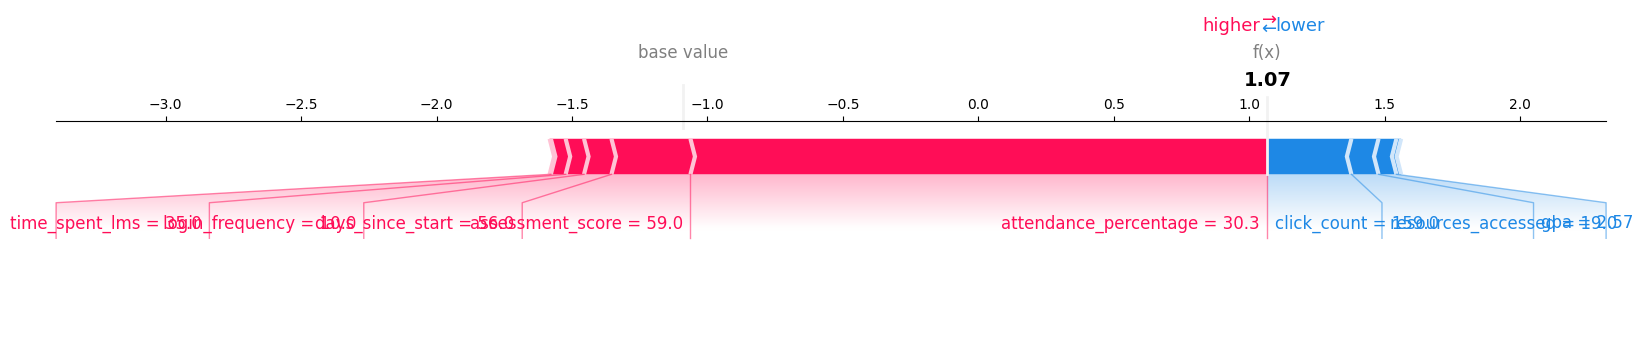

In [40]:
# Pull indices of students the model predicted as High Risk
high_risk_mask = (pred_xgb == high_risk_class_idx)
high_risk_students = X_test[high_risk_mask]

# Explain one specific High Risk student (e.g. the first one)
student_idx = 0
shap.force_plot(
    explainer.expected_value[high_risk_class_idx],
    shap_values[high_risk_mask][student_idx, :, high_risk_class_idx],
    high_risk_students.iloc[student_idx],
    feature_names=features,
    matplotlib=True
)

SCALE NUMERICAL FEATURES

In [38]:
# Recompute numerical columns after feature engineering
final_numerical_cols = df_encoded.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [ ]:
# Exclude IDs from scaling
exclude_from_scaling = ['student_id', 'week_number']
scale_cols = [c for c in final_numerical_cols if c not in exclude_from_scaling]

In [ ]:
scaler = StandardScaler()
df_encoded[scale_cols] = scaler.fit_transform(df_encoded[scale_cols])

9. FINAL CHECK

In [ ]:
print(df_encoded.shape)
df_encoded.head()

(6124, 8739)


,gpa,module_credits,ca_weight,final_exam_weight,ca_marks,final_exam_marks,total_marks,lecture_attendance,attendance_percentage,exam_results,...,module_id_MOD-IS2240,module_id_MOD-IS2901,pass_fail_status_Fail,pass_fail_status_Pass,week_number,days_since_start,engagement_score,assessment_ratio,weighted_score,low_attendance_flag
0,0.500158,0.318116,-0.084567,0.084567,0.197593,0.378915,0.615265,1.411534,1.555238,1.990131,...,False,False,False,True,6,-0.245939,0.779902,0.565133,0.109386,-1.273411
1,0.285854,2.303993,2.511376,-2.511376,2.583137,-2.047697,0.299880,-0.535445,-0.597368,-2.017016,...,False,False,False,True,8,0.893775,0.039775,0.274409,2.536483,0.785292
2,0.285854,-0.674822,-0.517225,0.517225,-0.524921,0.295045,-0.194842,0.172547,0.109537,0.251896,...,False,False,False,True,8,0.893775,0.039775,0.274409,-0.407273,0.785292
3,0.285854,0.318116,-0.084567,0.084567,-0.325607,-0.392681,-0.757588,-0.712443,-0.756821,-0.414157,...,False,False,False,True,8,0.893775,0.039775,0.274409,0.013263,0.785292
4,0.285854,-0.674822,-0.517225,0.517225,-0.686864,-0.135482,-0.831797,-0.535445,-0.485752,-0.165064,...,False,False,False,True,8,0.893775,0.039775,0.274409,-0.407273,0.785292
